# Cluster Results Analysis

Analyzes results from four server runs:
- **`beta_sweep`** — 21 β values, N=500, 20 k steps, baseline pool (`experiment_2` style)
- **`beta_sweep_disinfo`** — same but with 8 disinformation claims
- **`matrix_sweep`** — 5 biases × 6 rankers, N=500, 8 k steps, baseline pool (`experiment_rankers_vs_bias` style)
- **`matrix_sweep_disinfo`** — same but with 8 disinformation claims

In [16]:
%load_ext autoreload
%autoreload 2
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt
from rankers.viz import plot_metric_comparison, plot_matrix_grid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Part 1 — Beta Sweep

In [2]:
def load_beta_sweep(results_dir):
    sweep = {}
    files = sorted(glob.glob(f"{results_dir}/result_beta_*.pkl"))
    for path in files:
        with open(path, "rb") as f:
            data = pickle.load(f)
        sweep[data["beta"]] = data["result"]
    print(f"Loaded {len(sweep)} beta values from '{results_dir}'")
    return sweep

sweep        = load_beta_sweep("results/beta_sweep")
sweep_disinfo = load_beta_sweep("results/beta_sweep_disinfo")

betas = sorted(sweep.keys())
print(f"β values: {[f'{b:.3g}' for b in betas]}")

Loaded 21 beta values from 'results/beta_sweep'
Loaded 21 beta values from 'results/beta_sweep_disinfo'
β values: ['0', '1', '1.44', '2.07', '2.99', '4.3', '6.2', '8.93', '12.9', '18.5', '26.7', '38.4', '55.3', '79.7', '115', '165', '238', '343', '494', '711', '1.02e+03']


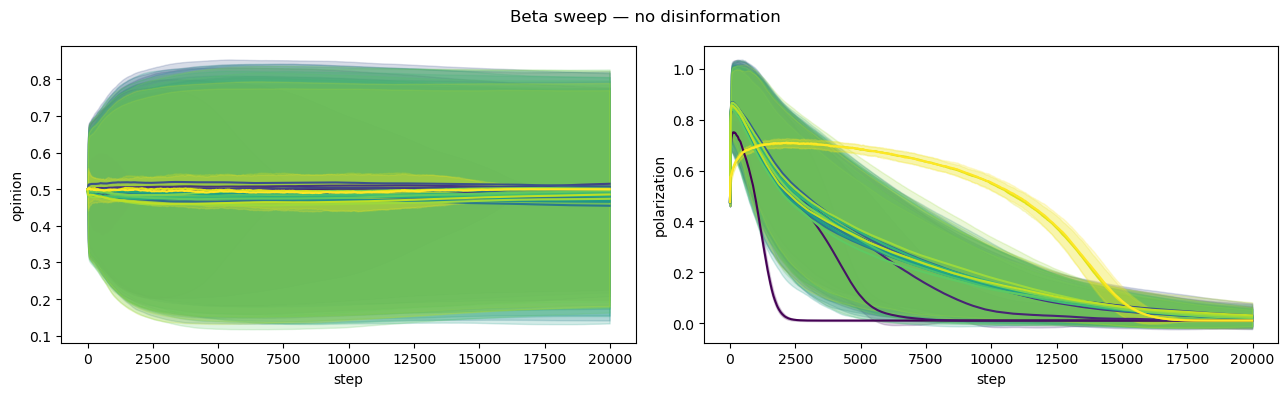

In [4]:
# Opinion & polarization trajectories — no disinformation
labels = [f"β = {b:g}" for b in betas]
aggs   = [sweep[b] for b in betas]

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4))
plot_metric_comparison(aggs, "opinion", "polarization", ax_l, ax_r, record_every=20)
fig.suptitle("Beta sweep — no disinformation", fontsize=12)
plt.tight_layout()
plt.show()

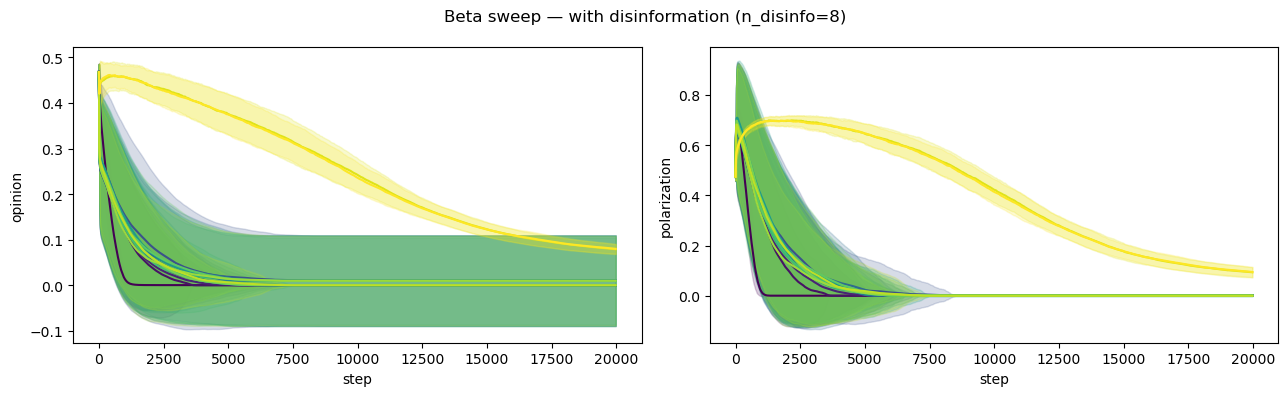

In [6]:
# Opinion & polarization trajectories — with disinformation (n_disinfo=8)
aggs_disinfo = [sweep_disinfo[b] for b in betas]

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4))
plot_metric_comparison(aggs_disinfo, "opinion", "polarization", ax_l, ax_r,
                       record_every=20)
fig.suptitle("Beta sweep — with disinformation (n_disinfo=8)", fontsize=12)
plt.tight_layout()
plt.show()

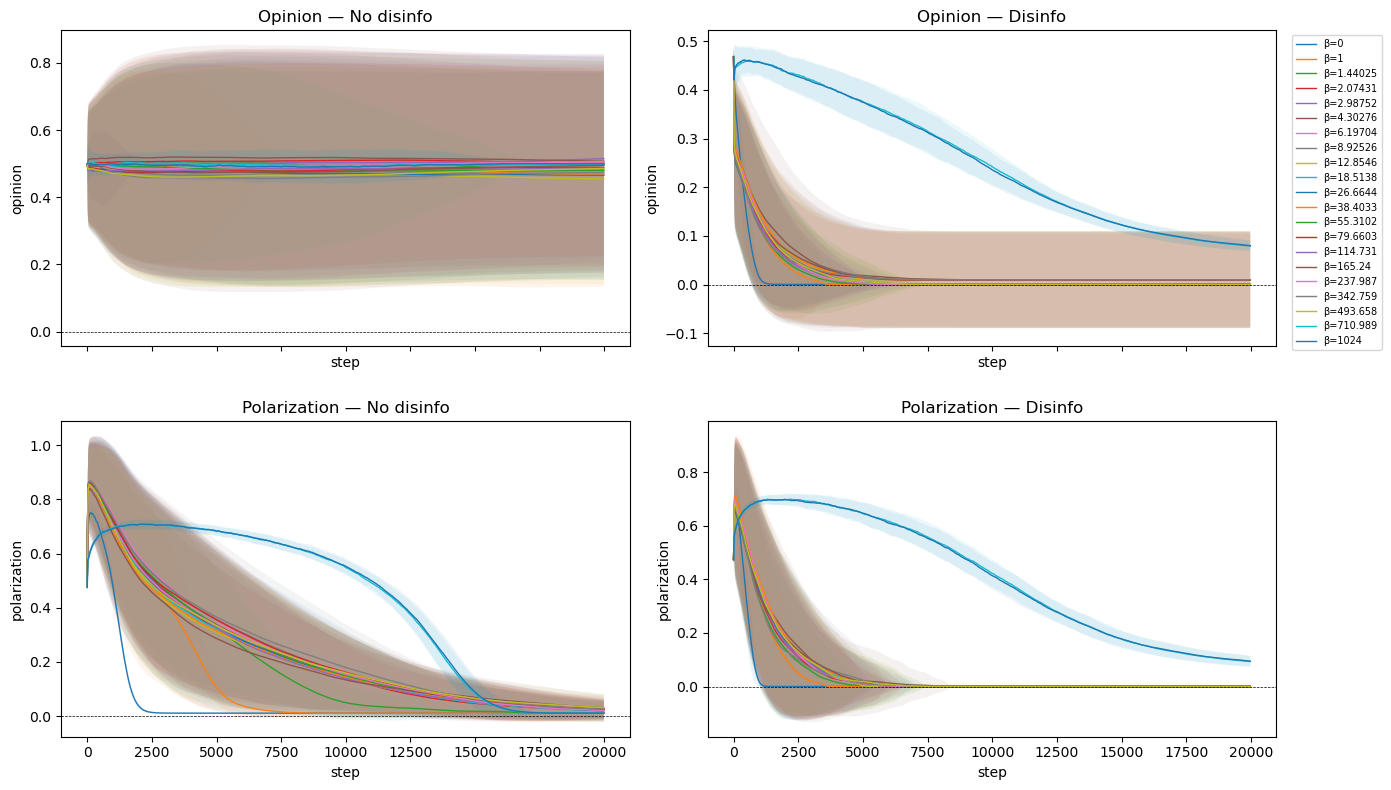

In [7]:
# Side-by-side: opinion and polarization for both conditions across all betas
RECORD_EVERY = 20

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")

for col, (sw, cond) in enumerate([(sweep, "No disinfo"), (sweep_disinfo, "Disinfo")]):
    for row, metric in enumerate(["opinion", "polarization"]):
        ax = axes[row, col]
        for beta in betas:
            m = sw[beta]["mean"][metric]
            s = sw[beta]["std"][metric]
            t = np.arange(len(m)) * RECORD_EVERY
            ax.plot(t, m, lw=1, label=f"β={beta:g}")
            ax.fill_between(t, m - s, m + s, alpha=0.08)
        ax.axhline(0, color="black", lw=0.5, ls="--")
        ax.set_title(f"{metric.capitalize()} — {cond}")
        ax.set_ylabel(metric)
        ax.set_xlabel("step")

axes[0, 1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()
plt.show()

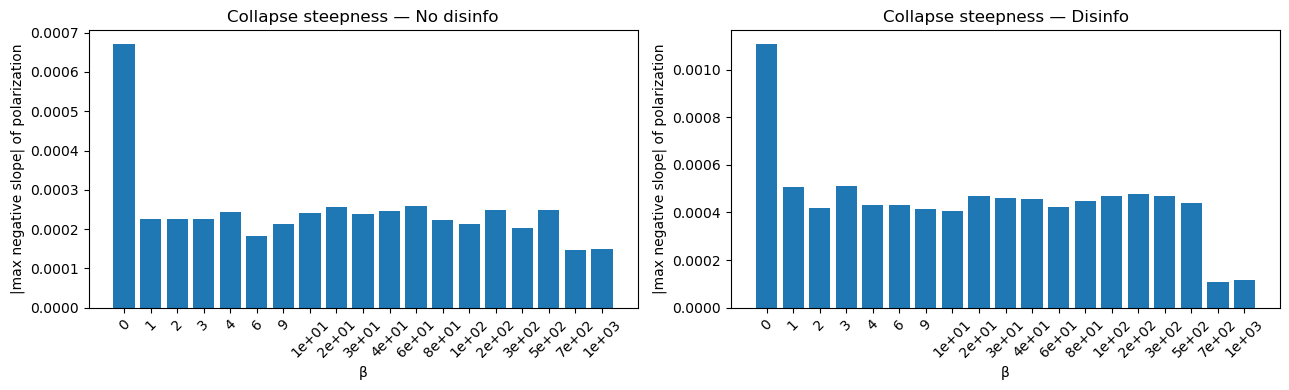

In [8]:
# Collapse steepness: max negative slope of polarization(t) per beta
def max_negative_slope(sw, betas, record_every=20):
    return {b: np.diff(sw[b]["mean"]["polarization"]).min() / record_every for b in betas}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (sw, title) in zip(axes, [(sweep, "No disinfo"), (sweep_disinfo, "Disinfo")]):
    slopes = max_negative_slope(sw, betas)
    ax.bar([f"{b:.1g}" for b in betas], [abs(slopes[b]) for b in betas])
    ax.set_xlabel("β")
    ax.set_ylabel("|max negative slope| of polarization")
    ax.set_title(f"Collapse steepness — {title}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

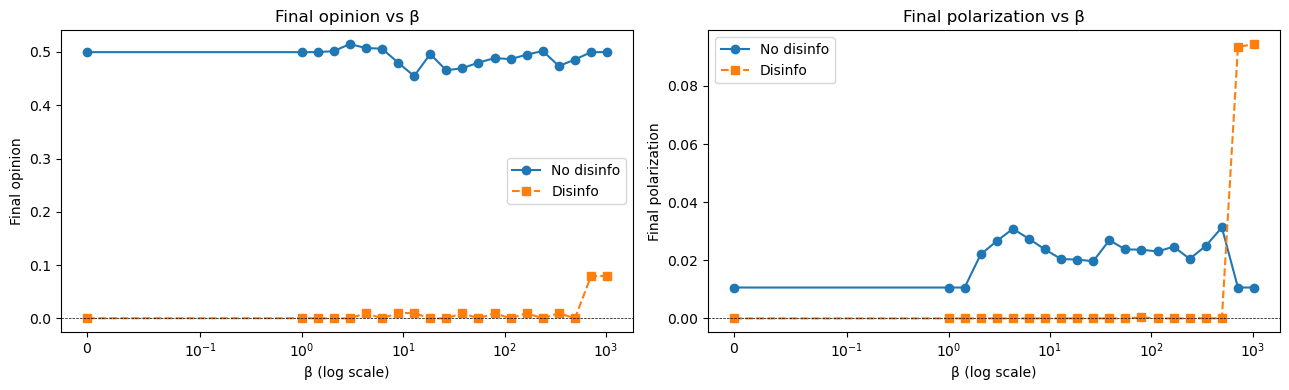

In [9]:
# Final values: opinion and polarization at last time step vs beta
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["opinion", "polarization"]):
    final_no = [sweep[b]["mean"][metric][-1]         for b in betas]
    final_di = [sweep_disinfo[b]["mean"][metric][-1] for b in betas]
    ax.plot(betas, final_no, "o-", label="No disinfo")
    ax.plot(betas, final_di, "s--", label="Disinfo")
    ax.set_xscale("symlog", linthresh=0.1)
    ax.set_xlabel("β (log scale)")
    ax.set_ylabel(f"Final {metric}")
    ax.set_title(f"Final {metric} vs β")
    ax.legend()
    ax.axhline(0, color="black", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

---
## Part 2 — Matrix Sweep (bias × ranker)

In [10]:
BIAS_NAMES   = ["baseline", "confirmation", "negativity", "illusory_truth", "conservatism"]
RANKER_NAMES = ["baseline", "similarity", "engagement", "post_popularity", "user_popularity", "chronological"]

def load_matrix_sweep(results_dir):
    matrix = {}
    files = sorted(glob.glob(f"{results_dir}/result_*.pkl"))
    for path in files:
        with open(path, "rb") as f:
            data = pickle.load(f)
        matrix.setdefault(data["bias_name"], {})[data["ranker_name"]] = data["result"]
    n = sum(len(v) for v in matrix.values())
    print(f"Loaded {n} conditions from '{results_dir}'")
    return matrix

matrix        = load_matrix_sweep("results/matrix_sweep")
matrix_disinfo = load_matrix_sweep("results/matrix_sweep_disinfo")

Loaded 30 conditions from 'results/matrix_sweep'
Loaded 30 conditions from 'results/matrix_sweep_disinfo'


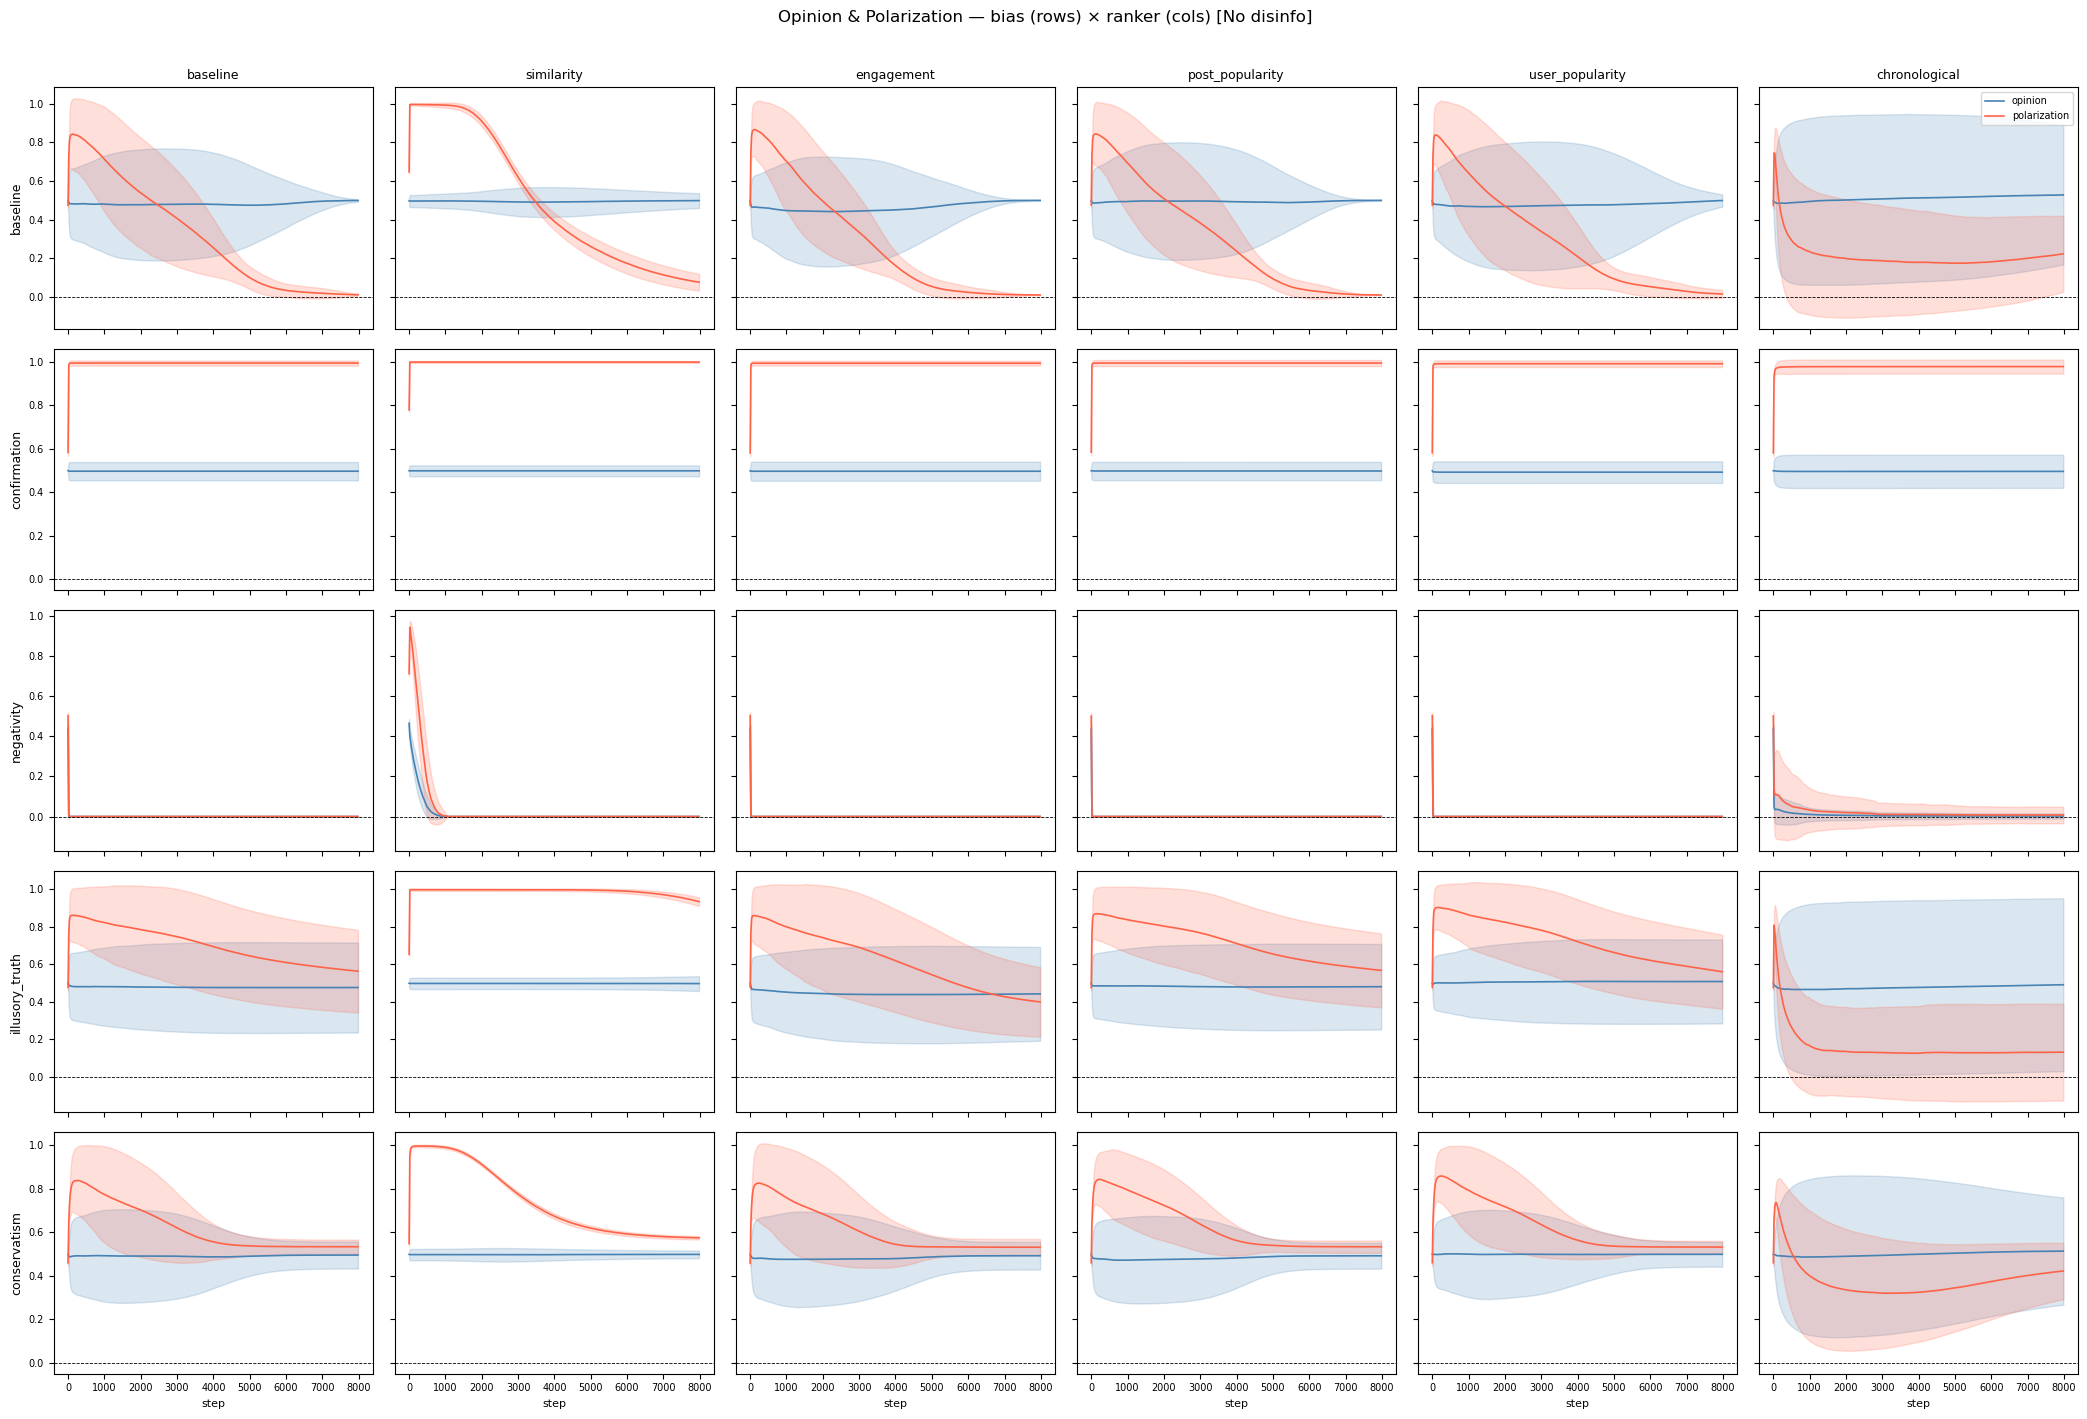

In [11]:
# Trajectory grid: bias (rows) × ranker (cols) — no disinformation
N, M = len(BIAS_NAMES), len(RANKER_NAMES)
RECORD_EVERY = 20

fig, axes = plt.subplots(N, M, figsize=(3.5 * M, 2.8 * N), sharex=True, sharey="row")

for i, bias in enumerate(BIAS_NAMES):
    for j, ranker in enumerate(RANKER_NAMES):
        ax = axes[i, j]
        agg = matrix[bias][ranker]
        for metric, color in [("opinion", "steelblue"), ("polarization", "tomato")]:
            m = agg["mean"][metric]
            s = agg["std"][metric]
            t = np.arange(len(m)) * RECORD_EVERY
            ax.plot(t, m, color=color, lw=1.2, label=metric)
            ax.fill_between(t, m - s, m + s, color=color, alpha=0.2)
        ax.axhline(0, color="black", lw=0.6, ls="--")
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.set_title(ranker, fontsize=9)
        if j == 0:
            ax.set_ylabel(bias, fontsize=9)
        if i == N - 1:
            ax.set_xlabel("step", fontsize=8)

axes[0, -1].legend(fontsize=7, loc="upper right")
fig.suptitle("Opinion & Polarization — bias (rows) × ranker (cols) [No disinfo]", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_8496\3580930264.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


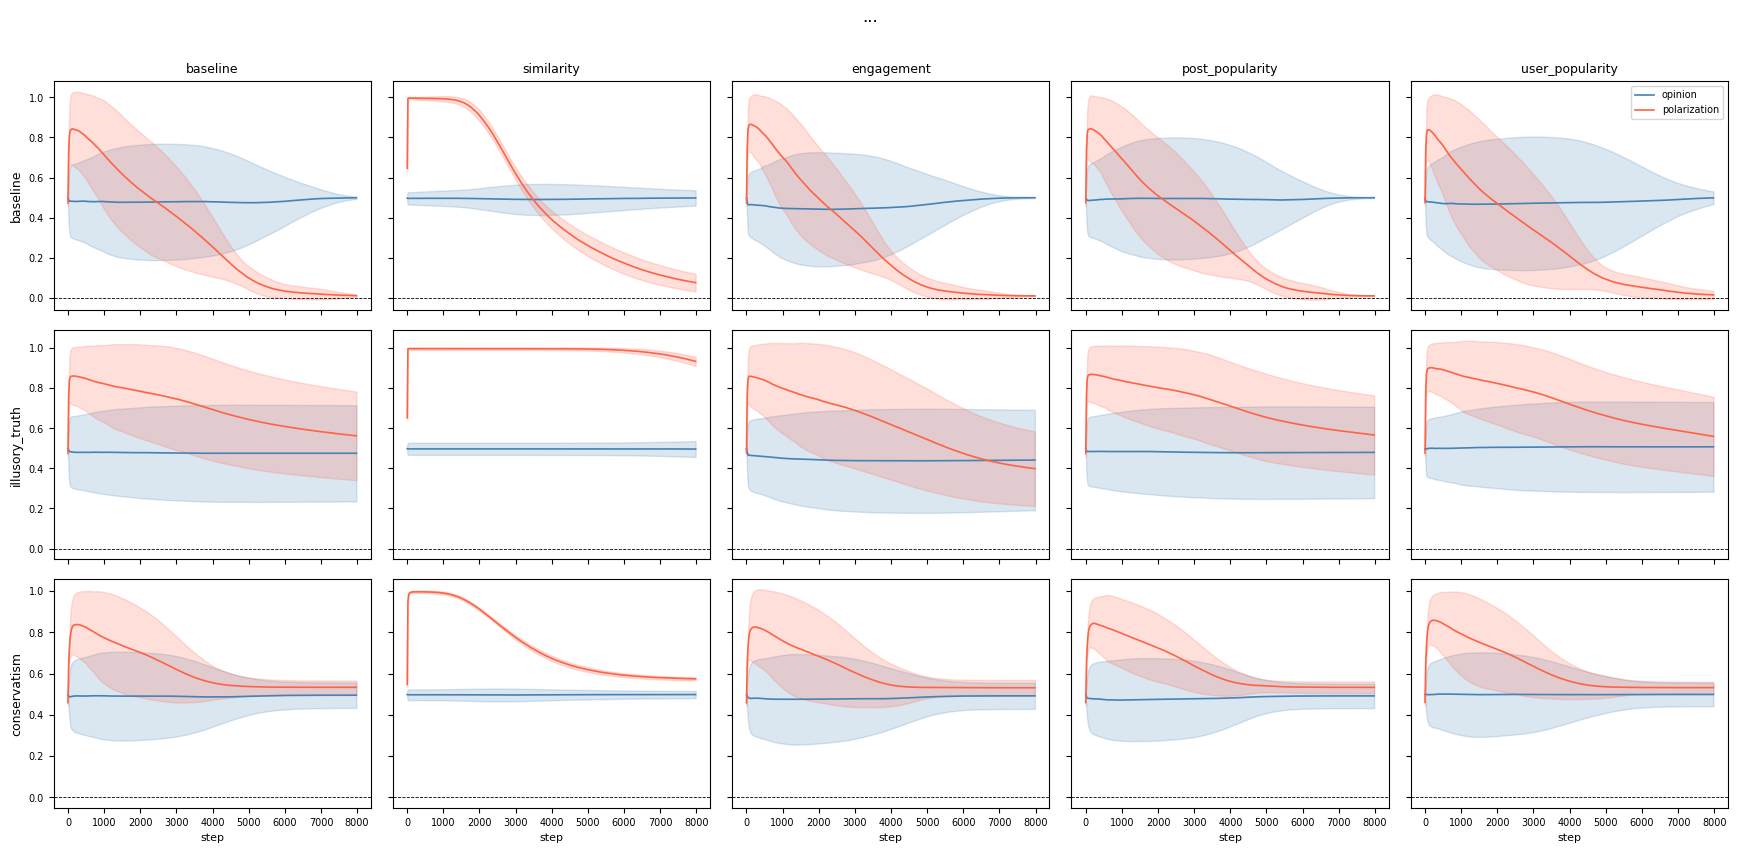

In [19]:
BIAS_NAMES   = ["baseline", "illusory_truth", "conservatism"]
RANKER_NAMES = ["baseline", "similarity", "engagement", "post_popularity", "user_popularity"]

plot_matrix_grid(matrix, bias_names=BIAS_NAMES, ranker_names=RANKER_NAMES, record_every=20, title="...")
fig.show()

C:\Users\nel_t\AppData\Local\Temp\ipykernel_8496\122765406.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


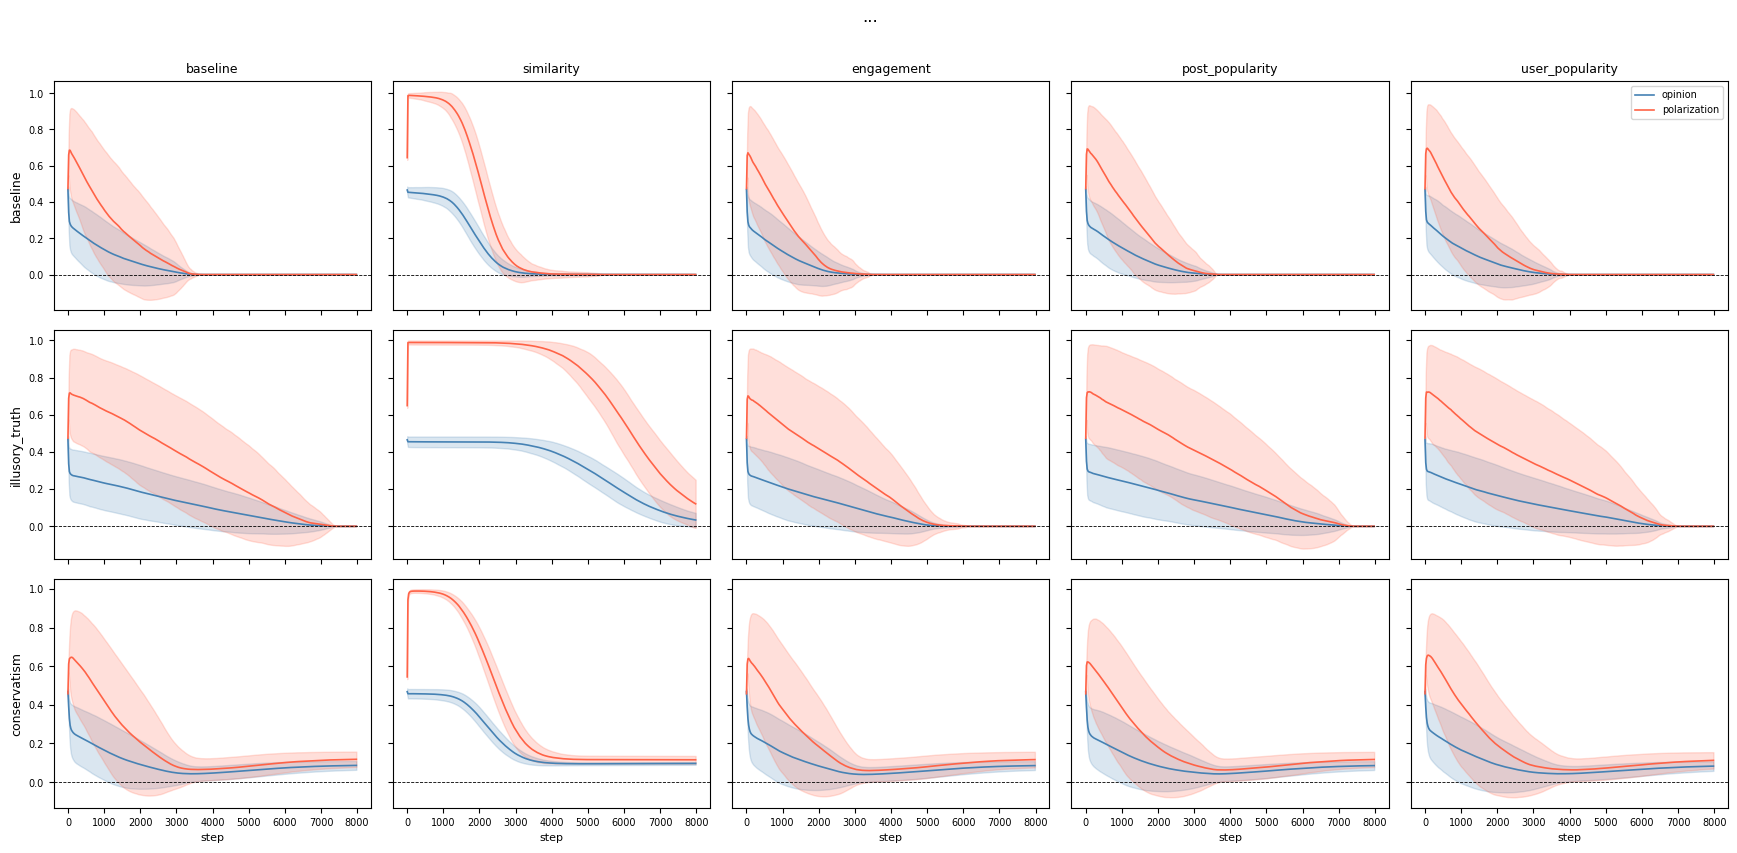

In [20]:
plot_matrix_grid(matrix_disinfo, bias_names=BIAS_NAMES, ranker_names=RANKER_NAMES, record_every=20, title="...")
fig.show()

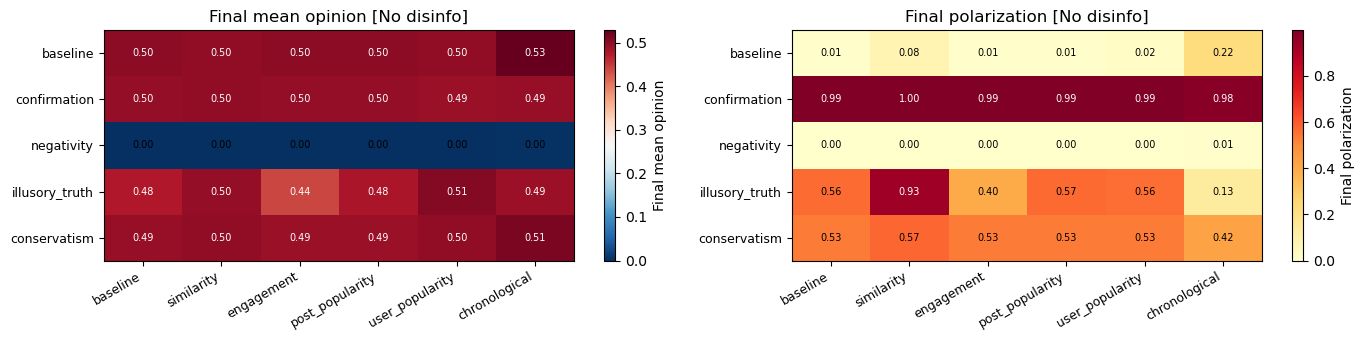

In [13]:
# Heatmaps: final opinion and polarization per (bias, ranker) — no disinformation
final_opinion      = np.array([[matrix[b][r]["mean"]["opinion"][-1]      for r in RANKER_NAMES] for b in BIAS_NAMES])
final_polarization = np.array([[matrix[b][r]["mean"]["polarization"][-1] for r in RANKER_NAMES] for b in BIAS_NAMES])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, data, title, cmap in [
    (axes[0], final_opinion,      "Final mean opinion",  "RdBu_r"),
    (axes[1], final_polarization, "Final polarization",  "YlOrRd"),
]:
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(RANKER_NAMES))); ax.set_xticklabels(RANKER_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(BIAS_NAMES)));   ax.set_yticklabels(BIAS_NAMES, fontsize=9)
    for i in range(len(BIAS_NAMES)):
        for j in range(len(RANKER_NAMES)):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(data[i, j]) > 0.6 * data.max() else "black")
    plt.colorbar(im, ax=ax, label=title)
    ax.set_title(f"{title} [No disinfo]")

plt.tight_layout()
plt.show()

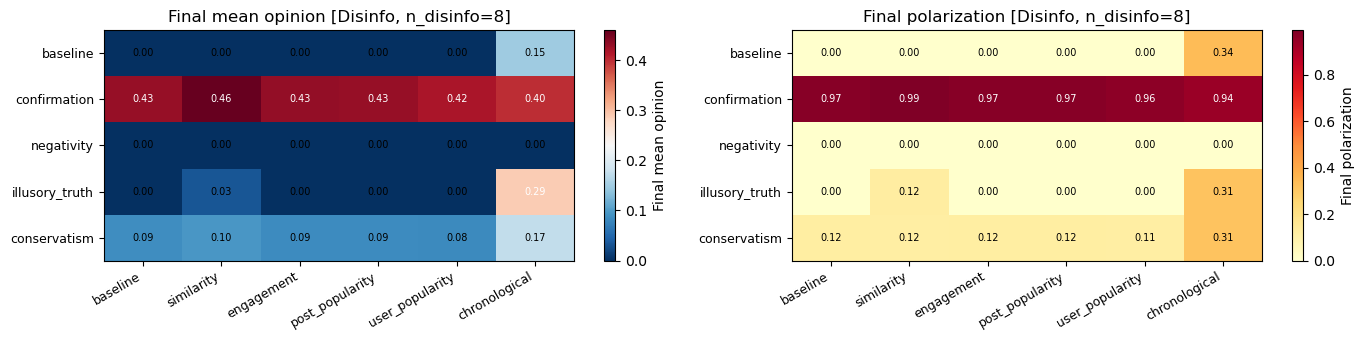

In [14]:
# Heatmaps: final opinion and polarization per (bias, ranker) — with disinformation
final_opinion_di      = np.array([[matrix_disinfo[b][r]["mean"]["opinion"][-1]      for r in RANKER_NAMES] for b in BIAS_NAMES])
final_polarization_di = np.array([[matrix_disinfo[b][r]["mean"]["polarization"][-1] for r in RANKER_NAMES] for b in BIAS_NAMES])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, data, title, cmap in [
    (axes[0], final_opinion_di,      "Final mean opinion",  "RdBu_r"),
    (axes[1], final_polarization_di, "Final polarization",  "YlOrRd"),
]:
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(RANKER_NAMES))); ax.set_xticklabels(RANKER_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(BIAS_NAMES)));   ax.set_yticklabels(BIAS_NAMES, fontsize=9)
    for i in range(len(BIAS_NAMES)):
        for j in range(len(RANKER_NAMES)):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(data[i, j]) > 0.6 * data.max() else "black")
    plt.colorbar(im, ax=ax, label=title)
    ax.set_title(f"{title} [Disinfo, n_disinfo=8]")

plt.tight_layout()
plt.show()

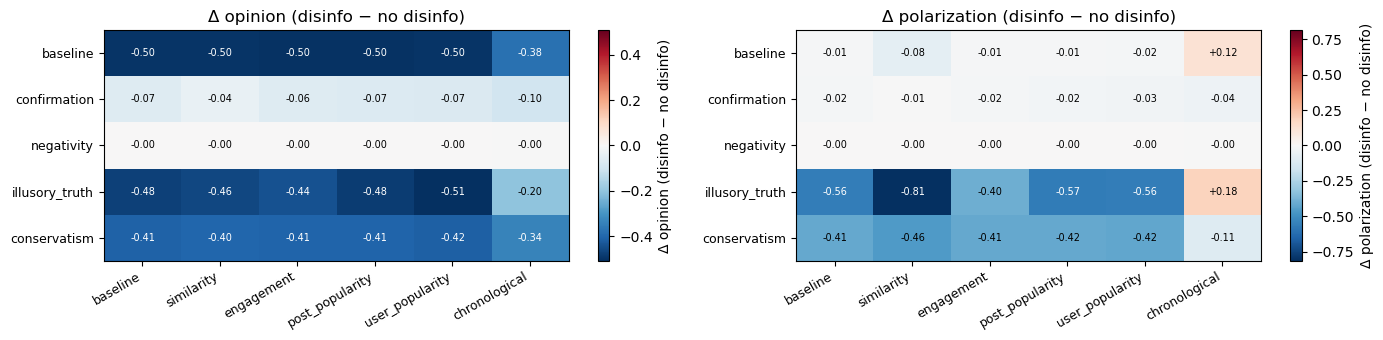

In [15]:
# Heatmaps of the difference (disinfo − no disinfo)
d_opinion      = final_opinion_di      - final_opinion
d_polarization = final_polarization_di - final_polarization

lim_op  = np.abs(d_opinion).max()
lim_pol = np.abs(d_polarization).max()

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, data, title, lim in [
    (axes[0], d_opinion,      "Δ opinion (disinfo − no disinfo)",      lim_op),
    (axes[1], d_polarization, "Δ polarization (disinfo − no disinfo)", lim_pol),
]:
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xticks(range(len(RANKER_NAMES))); ax.set_xticklabels(RANKER_NAMES, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(BIAS_NAMES)));   ax.set_yticklabels(BIAS_NAMES, fontsize=9)
    for i in range(len(BIAS_NAMES)):
        for j in range(len(RANKER_NAMES)):
            ax.text(j, i, f"{data[i, j]:+.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(data[i, j]) > 0.6 * lim else "black")
    plt.colorbar(im, ax=ax, label=title)
    ax.set_title(title)

plt.tight_layout()
plt.show()